# Newton-Raphson Method

The Newton-Raphson method is an iterative root-finding procedure for solving nonlinear equations of the form $f(x) = 0$. It belongs to the class of open methods and exploits information about the first derivative of the function.

## Formulation

Given a sufficiently smooth function $f : \mathbb{R} \to \mathbb{R}$, the Newton-Raphson iteration is defined by:

$$
x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}
$$

where $f'(x)$ denotes the first derivative of $f$. The update is derived from the linearization of $f$ around the current iterate $x_n$:

$$
f(x) \approx f(x_n) + f'(x_n) (x - x_n)
$$

and solving the linear approximation for zero.

## Convergence Properties

- Local convergence: if $x^*$ is a simple root ($f(x^*) = 0$, $f'(x^*) \neq 0$) and $f$ is twice continuously differentiable in a neighborhood of $x^*$, then the iterates converge to $x^*$ for a sufficiently close initial guess $x_0$.
- Quadratic convergence: near a simple root, the error satisfies

$$
|x_{n+1} - x^*| \approx C \, |x_n - x^*|^2
$$

where $C = \left|\frac{f''(x^*)}{2 f'(x^*)}\right|$. The squared dependence implies rapid convergence once the iterate is close enough.

## Assumptions and Limitations

- Requirement for derivative: $f'(x_n)$ must be evaluated, so the method is applicable when the derivative is available analytically or can be computed numerically with adequate accuracy.
- Nonzero derivative: the method fails if $f'(x_n) = 0$ at an iterate or at the root, since the iteration formula becomes singular.
- Sensitivity to initial guess: convergence is not guaranteed globally. A poor initial guess may lead to divergence, cycling, or convergence to an unintended root.
- Multiple roots: if $x^*$ is a root of multiplicity $m > 1$, the convergence rate degrades to linear rather than quadratic, unless modifications are applied.

## Algorithmic Structure

1. Choose initial approximation $x_0$.
2. Repeat until convergence:
    - Evaluate $f(x_n)$ and $f'(x_n)$.
    - Compute $x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}$.
    - Assess convergence using criteria such as $|x_{n+1} - x_n| < \text{tol}$ or $|f(x_{n+1})| < \text{tol}$.
3. Terminate when tolerance is satisfied or maximum iterations reached.

## Practical Considerations

- Safeguarding: hybrid methods often combine Newton-Raphson with bracketing techniques to ensure global convergence.
- Step control: damping or line search can stabilize the iteration by replacing the update with $x_{n+1} = x_n - \lambda \frac{f(x_n)}{f'(x_n)}$ for $0 < \lambda \le 1$.
- Higher dimensions: the method generalizes to systems of equations using the Jacobian matrix $J(x)$:

$$
x_{n+1} = x_n - J(x_n)^{-1} f(x_n)
$$

where $f : \mathbb{R}^n \to \mathbb{R}^n$.

## Summary

Newton-Raphson is a fundamental iterative method in numerical analysis for finding roots of nonlinear equations. Its primary strengths are simplicity and quadratic convergence near simple roots. Its main weaknesses are the need for derivative information and the lack of guaranteed global convergence without additional safeguards.

Radice trovata: 2.0945514815423265


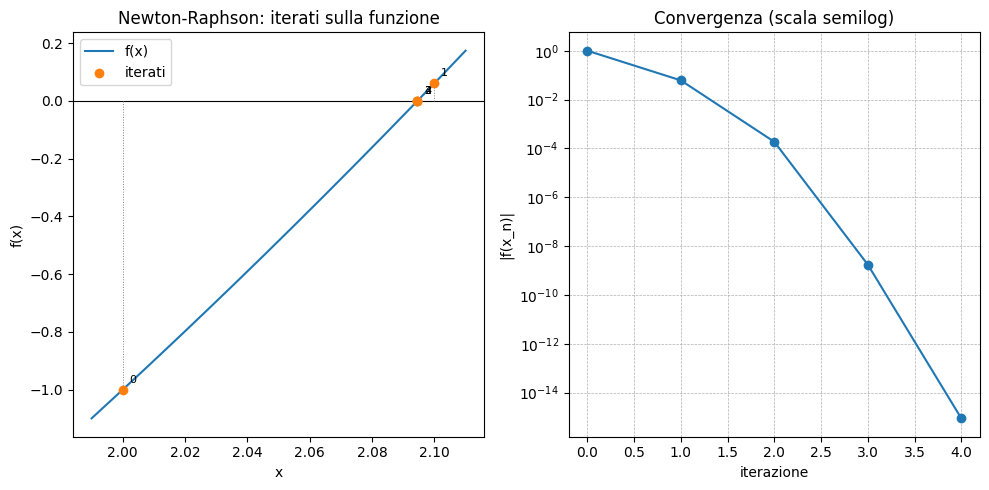

In [1]:
import numpy as np

import matplotlib.pyplot as plt

def newton_raphson(f, df, x0, tol=1e-10, maxiter=50, damping=1.0):
    """
    Restituisce (root, iterates_list).
    """
    x = float(x0)
    xs = [x]
    for k in range(1, maxiter+1):
        fx = f(x)
        dfx = df(x)
        if abs(dfx) < 1e-14:
            raise ZeroDivisionError(f"Derivata prossima a zero in iter {k}: x={x}")
        dx = damping * fx / dfx
        x_new = x - dx
        xs.append(x_new)
        if abs(x_new - x) < tol or abs(f(x_new)) < tol:
            return x_new, xs
        x = x_new
    return x, xs

def plot_newton(f, xs, xpad=0.1, npoints=400, figsize=(10,5)):
    """
    Grafico della funzione con gli iterati e grafico della convergenza |f(x_n)|.
    xs: lista di iterati (in ordine).
    """
    xs_arr = np.array(xs)
    x_min, x_max = xs_arr.min(), xs_arr.max()
    span = x_max - x_min
    if span == 0:
        span = 1.0
    x_low = x_min - xpad*span
    x_high = x_max + xpad*span
    xs_plot = np.linspace(x_low, x_high, npoints)
    ys_plot = np.array([f(xx) for xx in xs_plot])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    # funzione e iterati
    ax1.plot(xs_plot, ys_plot, label='f(x)')
    ax1.axhline(0, color='k', linewidth=0.8)
    ax1.scatter(xs_arr, [f(x) for x in xs_arr], color='C1', zorder=5, label='iterati')
    for i, xi in enumerate(xs_arr):
        ax1.annotate(f'{i}', (xi, f(xi)), textcoords="offset points", xytext=(5,5), fontsize=8)
        ax1.vlines(xi, 0, f(xi), linestyles='dotted', colors='gray', linewidth=0.7)
    ax1.set_xlabel('x')
    ax1.set_ylabel('f(x)')
    ax1.set_title('Newton-Raphson: iterati sulla funzione')
    ax1.legend()

    # convergenza
    fvals = np.array([abs(f(x)) for x in xs_arr])
    ax2.semilogy(range(len(xs_arr)), fvals, marker='o')
    ax2.set_xlabel('iterazione')
    ax2.set_ylabel('|f(x_n)|')
    ax2.set_title('Convergenza (scala semilog)')
    ax2.grid(True, which='both', ls='--', lw=0.5)

    plt.tight_layout()
    plt.show()

# Esempio di utilizzo:
if __name__ == "__main__":
    # definire funzione e derivata
    def f(x): return x**3 - 2*x - 5
    def df(x): return 3*x**2 - 2

    root, iterates = newton_raphson(f, df, x0=2.0, tol=1e-12, maxiter=50)
    print("Radice trovata:", root)
    plot_newton(f, iterates)